In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings ('ignore')

In [2]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = "#800000"
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [3]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding= 'latin-1')

In [4]:
# Overview
print("rows, cols:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nNum duplicates:", df.duplicated().sum())

print("\nMissing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [5]:
df

#DATA CLEANING
#columns_to_drop = ['Product Description','Order Zipcode']


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [6]:
df = df.drop(['Product Description', 'Order Zipcode'], axis=1)

In [7]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Shanghái,CLOSED,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Osaka,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Australia del Sur,PENDING,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Australia del Sur,PENDING_PAYMENT,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [8]:
df['Product Status'].unique()

array([0])

In [9]:
df = df.drop(['Product Status'], axis=1)

In [10]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Eastern Asia,Shanghái,CLOSED,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Eastern Asia,Osaka,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Oceania,Australia del Sur,PENDING,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Oceania,Australia del Sur,PENDING_PAYMENT,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/18/2016 20:18,Standard Class


In [11]:
df.groupby('Category Name')['Category Id'].nunique()

Category Name
Accessories             1
As Seen on  TV!         1
Baby                    1
Baseball & Softball     1
Basketball              1
Books                   1
Boxing & MMA            1
CDs                     1
Cameras                 1
Camping & Hiking        1
Cardio Equipment        1
Children's Clothing     1
Cleats                  1
Computers               1
Consumer Electronics    1
Crafts                  1
DVDs                    1
Electronics             2
Fishing                 1
Fitness Accessories     1
Garden                  1
Girls' Apparel          1
Golf Apparel            1
Golf Bags & Carts       1
Golf Balls              1
Golf Gloves             1
Golf Shoes              1
Health and Beauty       1
Hockey                  1
Hunting & Shooting      1
Indoor/Outdoor Games    1
Kids' Golf Clubs        1
Lacrosse                1
Men's Clothing          1
Men's Footwear          1
Men's Golf Clubs        1
Music                   1
Pet Supplies            

In [12]:
df[df['Category Name'] == 'Electronics']

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
55,PAYMENT,2,2,22.410000,74.680000,Shipping on time,0,13,Electronics,Caguas,...,West of USA,Washington,PENDING_PAYMENT,278,13,http://images.acmesports.sports/Under+Armour+M...,Under Armour Men's Compression EV SL Slide,44.990002,6/13/2016 15:12,Second Class
62,PAYMENT,5,2,38.230000,79.660004,Late delivery,1,37,Electronics,Caguas,...,North Africa,Gran Casablanca,PENDING_PAYMENT,828,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL San Dieg,31.990000,12/13/2016 0:14,Second Class
115,TRANSFER,5,4,29.690001,237.550003,Late delivery,1,37,Electronics,Caguas,...,Central America,San Salvador,PENDING,818,37,http://images.acmesports.sports/Titleist+Pro+V...,Titleist Pro V1x Golf Balls,47.990002,4/2/2017 5:20,Standard Class
116,TRANSFER,4,4,73.699997,153.550003,Shipping on time,0,37,Electronics,Caguas,...,Central America,Nayarit,PENDING,825,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL Tennesse,31.990000,2/9/2017 1:01,Standard Class
177,DEBIT,4,2,12.530000,43.189999,Late delivery,1,13,Electronics,Caguas,...,Northern Europe,Inglaterra,COMPLETE,278,13,http://images.acmesports.sports/Under+Armour+M...,Under Armour Men's Compression EV SL Slide,44.990002,10/6/2015 7:40,Second Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179563,TRANSFER,3,4,70.540001,156.750000,Advance shipping,0,37,Electronics,Caguas,...,Eastern Europe,Bélgorod,PROCESSING,825,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL Tennesse,31.990000,12/13/2016 14:35,Standard Class
179565,TRANSFER,4,4,74.379997,148.750000,Shipping on time,0,37,Electronics,Caguas,...,Northern Europe,Inglaterra,PROCESSING,825,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL Tennesse,31.990000,9/25/2015 0:09,Standard Class
179567,TRANSFER,5,4,84.809998,226.160004,Late delivery,1,37,Electronics,Caguas,...,Western Europe,Viena,PROCESSING,823,37,http://images.acmesports.sports/Titleist+Pro+V...,Titleist Pro V1x High Numbers Personalized Go,51.990002,10/7/2015 2:46,Standard Class
179568,TRANSFER,3,4,-212.410004,132.759995,Advance shipping,0,37,Electronics,Caguas,...,Southern Europe,Murcia,PROCESSING,828,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL San Dieg,31.990000,9/10/2015 11:44,Standard Class


In [13]:
df['Category Id'] = df['Category Id'].replace([13, 37], 1337)

In [14]:
df[df['Category Name'] == 'Electronics']

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
55,PAYMENT,2,2,22.410000,74.680000,Shipping on time,0,1337,Electronics,Caguas,...,West of USA,Washington,PENDING_PAYMENT,278,13,http://images.acmesports.sports/Under+Armour+M...,Under Armour Men's Compression EV SL Slide,44.990002,6/13/2016 15:12,Second Class
62,PAYMENT,5,2,38.230000,79.660004,Late delivery,1,1337,Electronics,Caguas,...,North Africa,Gran Casablanca,PENDING_PAYMENT,828,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL San Dieg,31.990000,12/13/2016 0:14,Second Class
115,TRANSFER,5,4,29.690001,237.550003,Late delivery,1,1337,Electronics,Caguas,...,Central America,San Salvador,PENDING,818,37,http://images.acmesports.sports/Titleist+Pro+V...,Titleist Pro V1x Golf Balls,47.990002,4/2/2017 5:20,Standard Class
116,TRANSFER,4,4,73.699997,153.550003,Shipping on time,0,1337,Electronics,Caguas,...,Central America,Nayarit,PENDING,825,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL Tennesse,31.990000,2/9/2017 1:01,Standard Class
177,DEBIT,4,2,12.530000,43.189999,Late delivery,1,1337,Electronics,Caguas,...,Northern Europe,Inglaterra,COMPLETE,278,13,http://images.acmesports.sports/Under+Armour+M...,Under Armour Men's Compression EV SL Slide,44.990002,10/6/2015 7:40,Second Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179563,TRANSFER,3,4,70.540001,156.750000,Advance shipping,0,1337,Electronics,Caguas,...,Eastern Europe,Bélgorod,PROCESSING,825,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL Tennesse,31.990000,12/13/2016 14:35,Standard Class
179565,TRANSFER,4,4,74.379997,148.750000,Shipping on time,0,1337,Electronics,Caguas,...,Northern Europe,Inglaterra,PROCESSING,825,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL Tennesse,31.990000,9/25/2015 0:09,Standard Class
179567,TRANSFER,5,4,84.809998,226.160004,Late delivery,1,1337,Electronics,Caguas,...,Western Europe,Viena,PROCESSING,823,37,http://images.acmesports.sports/Titleist+Pro+V...,Titleist Pro V1x High Numbers Personalized Go,51.990002,10/7/2015 2:46,Standard Class
179568,TRANSFER,3,4,-212.410004,132.759995,Advance shipping,0,1337,Electronics,Caguas,...,Southern Europe,Murcia,PROCESSING,828,37,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL San Dieg,31.990000,9/10/2015 11:44,Standard Class


In [15]:
df = df.drop('Category Id', axis=1)

In [16]:
df


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,South Asia,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,Oceania,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,Fishing,Brooklyn,EE. UU.,...,Eastern Asia,Shanghái,CLOSED,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,Fishing,Bakersfield,EE. UU.,...,Eastern Asia,Osaka,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,Fishing,Bristol,EE. UU.,...,Oceania,Australia del Sur,PENDING,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,Fishing,Caguas,Puerto Rico,...,Oceania,Australia del Sur,PENDING_PAYMENT,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/18/2016 20:18,Standard Class


In [17]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [18]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [19]:
df = df.drop(['Customer Lname', 'Customer Password'], axis=1)

In [20]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [21]:
is_redundant = (
    df.groupby('Benefit per order')['Order Profit Per Order'].nunique().max() == 1 and
    df.groupby('Order Profit Per Order')['Benefit per order'].nunique().max() == 1
)

if is_redundant:
    df = df.drop('Order Profit Per Order', axis=1)

In [22]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [23]:
df = df.drop(['Customer Email', 'Customer Fname', 'Customer Id'], axis=1)

In [24]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [25]:
num_cols = df.shape[1]
num_cols

43

In [26]:
df =df.drop(['Department Id'], axis=1)

In [27]:
df = df.drop(['Product Card Id', 'Product Category Id'], axis=1)

In [28]:
num_cols = df.shape[1]
num_cols

40

In [29]:
df = df.drop (['Order Item Cardprod Id'], axis=1)

In [30]:
df = df.drop (['Order Id'], axis=1)

In [31]:
num_cols = df.shape[1]
num_cols

38

In [32]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [33]:
df = df[df['Delivery Status'] != 'Shipping canceled']

In [34]:
df.shape[0]

172765

In [35]:
# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# After data cleaning, check overview again
print("rows, cols:", df.shape)

print("\nMissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

rows, cols: (172765, 38)

Missing values (top 10):
Customer Zipcode                 3
Type                             0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Days for shipping (real)         0
Delivery Status                  0
Late_delivery_risk               0
Customer City                    0
Category Name                    0
dtype: int64


In [36]:
df['order date (DateOrders)'].head()

0   2018-01-31 22:56:00
1   2018-01-13 12:27:00
2   2018-01-13 12:06:00
3   2018-01-13 11:45:00
4   2018-01-13 11:24:00
Name: order date (DateOrders), dtype: datetime64[ns]

In [37]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Sales,Order Item Total,Order Region,Order State,Order Status,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,327.750000,314.640015,Southeast Asia,Java Occidental,COMPLETE,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,327.750000,311.359985,South Asia,Rajastán,PENDING,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,327.750000,309.720001,South Asia,Rajastán,CLOSED,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,327.750000,304.809998,Oceania,Queensland,COMPLETE,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,327.750000,298.250000,Oceania,Queensland,PENDING_PAYMENT,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,2018-01-15 11:24:00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,Fishing,Brooklyn,EE. UU.,...,399.980011,399.980011,Eastern Asia,Shanghái,CLOSED,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-20 03:40:00,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,Fishing,Bakersfield,EE. UU.,...,399.980011,395.980011,Eastern Asia,Osaka,COMPLETE,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-19 01:34:00,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,Fishing,Bristol,EE. UU.,...,399.980011,391.980011,Oceania,Australia del Sur,PENDING,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-20 21:00:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,Fishing,Caguas,Puerto Rico,...,399.980011,387.980011,Oceania,Australia del Sur,PENDING_PAYMENT,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-18 20:18:00,Standard Class


In [38]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 15:
        print(f"\n{col} value counts:")
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Department Name value counts:
Department Name
Fan 

In [39]:
# calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Customer Zipcode,Latitude,Longitude,Order Customer Id,order date (DateOrders),...,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172762.000000,172765.000000,172765.000000,172765.000000,172765,...,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,22.032360,183.165948,0.572900,35931.612849,29.724145,-84.912610,6687.759048,2016-06-12 15:25:39.457991936,...,0.120801,2.127694,203.828493,183.165948,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,603.000000,-33.937553,-158.025986,1.000000,2015-01-01 00:00:00,...,-2.750000,1.000000,9.990000,7.490000,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,7.030000,104.379997,0.000000,725.000000,18.265436,-98.443069,3252.000000,2015-09-21 18:01:00,...,0.080000,1.000000,119.980003,104.379997,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,19380.000000,33.144863,-76.847908,6457.000000,2016-06-11 08:11:00,...,0.270000,1.000000,199.919998,163.990005,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,78207.000000,39.279617,-66.370583,9782.000000,2017-02-28 21:08:00,...,0.360000,3.000000,299.950012,247.399994,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,99205.000000,48.781933,115.263077,20757.000000,2018-01-31 23:38:00,...,0.500000,5.000000,1999.989990,1939.989990,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,104.355313,120.141871,0.494659,37537.273628,9.811816,21.410511,4165.069180,NaN,...,0.466610,1.453663,132.392520,120.141871,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [40]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour']


In [41]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [42]:
df['Profit_Status'] = np.where(
    df['Benefit per order'] > 0, 'Profit',
    np.where(df['Benefit per order'] < 0, 'Loss', 'Breakeven')
)

In [43]:
df['Profit_Status'].value_counts()

Profit_Status
Profit       139354
Loss          32295
Breakeven      1116
Name: count, dtype: int64

In [44]:
df['Profit_Status'].value_counts(normalize=True)

Profit_Status
Profit       0.80661
Loss         0.18693
Breakeven    0.00646
Name: proportion, dtype: float64

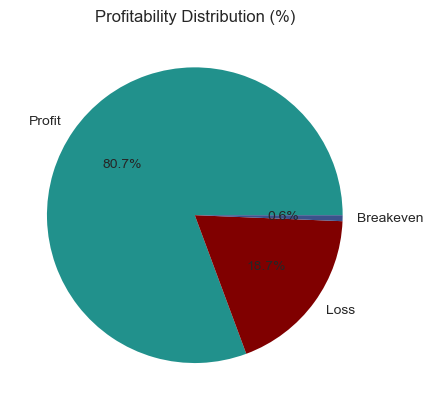

In [45]:
# visualization of profitability distribution
profit_counts = df['Profit_Status'].value_counts(normalize=True) * 100

plt.figure()
profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [46]:
# Total Orders
total_orders = len(df)

# Total Revenue
total_revenue = df['Sales'].sum()

# Total Profit
total_profit = df['Benefit per order'].sum()

# Average Order Value
aov = df['Sales'].mean()

# Profit Margin (%)
profit_margin = (total_profit / total_revenue) * 100

In [47]:
# On-time vs Late
on_time = (df['Is_Delayed'] == False).sum()
late = (df['Is_Delayed'] == True).sum()

on_time_pct = (on_time / total_orders) * 100
late_pct = (late / total_orders) * 100

In [48]:
# Total delay days
total_delay_days = df['Delay'][df['Delay'] > 0].sum()

# Average delay (only delayed orders)
avg_delay = df[df['Delay'] > 0]['Delay'].mean()

# Loss due to delays (only delayed orders with negative profit)
loss_due_to_delay = df[
    (df['Is_Delayed'] == True) & (df['Benefit per order'] < 0)
]['Benefit per order'].sum()

In [49]:
# Profit / Loss distribution
profit_orders = (df['Profit_Status'] == 'Profit').sum()
loss_orders = (df['Profit_Status'] == 'Loss').sum()
breakeven_orders = (df['Profit_Status'] == 'Breakeven').sum()

profit_pct = (profit_orders / total_orders) * 100
loss_pct = (loss_orders / total_orders) * 100

In [50]:
# Top performing segment
top_segment = df.groupby('Customer Segment')['Sales'].sum().idxmax()

# Most profitable category
top_category = df.groupby('Category Name')['Benefit per order'].sum().idxmax()

# Average discount
avg_discount = df['Order Item Discount'].mean()

# Orders with discount impact
discount_impact = df.groupby('Order Item Discount')['Benefit per order'].mean()

In [51]:
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: {total_revenue:.2f}")
print(f"Total Profit: {total_profit:.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

print(f"\nOn-time Delivery: {on_time_pct:.2f}%")
print(f"Late Delivery: {late_pct:.2f}%")

print(f"\nAvg Delay (days): {avg_delay:.2f}")
print(f"Total Delay Days: {total_delay_days}")
print(f"Loss Due to Delays: {loss_due_to_delay:.2f}")

print(f"\nProfit Orders: {profit_pct:.2f}%")
print(f"Loss Orders: {loss_pct:.2f}%")

print(f"\nTop Segment: {top_segment}")
print(f"Top Category: {top_category}")

Total Orders: 172765
Total Revenue: 35214429.65
Total Profit: 3806420.63
Profit Margin: 10.81%

On-time Delivery: 45.29%
Late Delivery: 54.71%

Avg Delay (days): 1.65
Total Delay Days: 155709
Loss Due to Delays: -2055609.66

Profit Orders: 80.66%
Loss Orders: 18.69%

Top Segment: Consumer
Top Category: Fishing


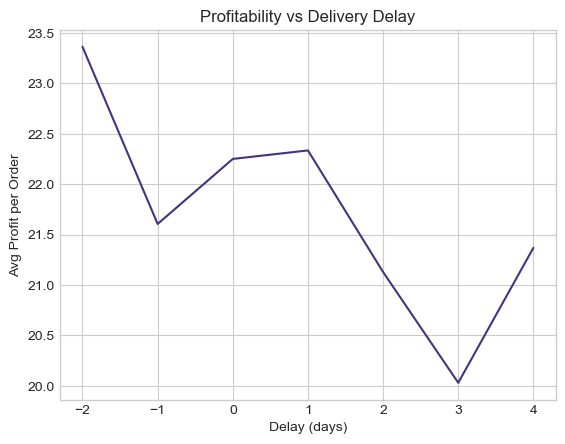

In [52]:
# Average profit by delay
profit_vs_delay = df.groupby('Delay')['Benefit per order'].mean()

plt.figure()
profit_vs_delay.plot()
plt.xlabel('Delay (days)')
plt.ylabel('Avg Profit per Order')
plt.title('Profitability vs Delivery Delay')
plt.show()

In [54]:
df['Delay_Bucket'] = pd.cut(
    df['Delay'],
    bins=[-np.inf, 0, 2, 5],
    labels=['On Time', '1-2 Days Late', '3-5 Days Late']
)

In [55]:
# Core profit metrics
total_profit = df['Benefit per order'].sum()
avg_profit = df['Benefit per order'].mean()

# Profit by delay bucket
profit_by_delay = df.groupby('Delay_Bucket')['Benefit per order'].agg(['mean', 'sum', 'count'])

# Profit margin by delay bucket
revenue_by_delay = df.groupby('Delay_Bucket')['Sales'].sum()
profit_margin_by_delay = (profit_by_delay['sum'] / revenue_by_delay) * 100

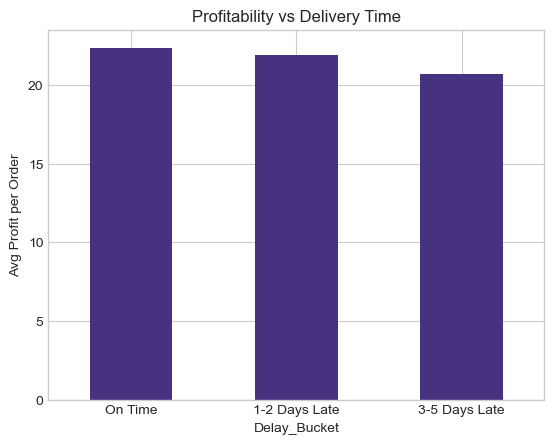

In [56]:
plt.figure()
df.groupby('Delay_Bucket')['Benefit per order'].mean().plot(kind='bar')
plt.ylabel('Avg Profit per Order')
plt.title('Profitability vs Delivery Time')
plt.xticks(rotation=0)
plt.show()

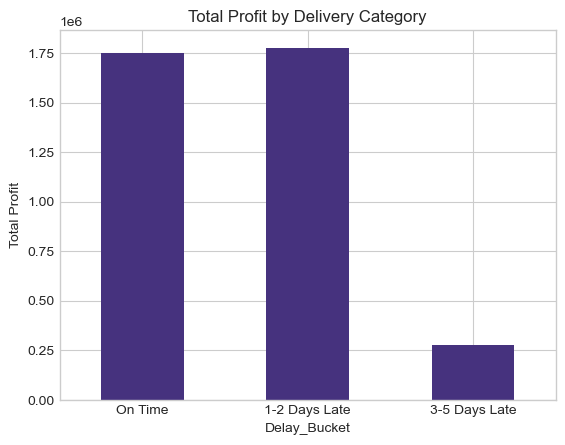

In [57]:
plt.figure()
df.groupby('Delay_Bucket')['Benefit per order'].sum().plot(kind='bar')
plt.ylabel('Total Profit')
plt.title('Total Profit by Delivery Category')
plt.xticks(rotation=0)
plt.show()

In [58]:
profit_metrics = (
    df.groupby('Delay')['Benefit per order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [59]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index

delay_distribution


<bound method Series.reset_index of Delay
-2    12.081730
-1    11.992591
 0    21.213788
 1    30.968657
 2    15.947096
 3     3.919775
 4     3.876364
Name: proportion, dtype: float64>

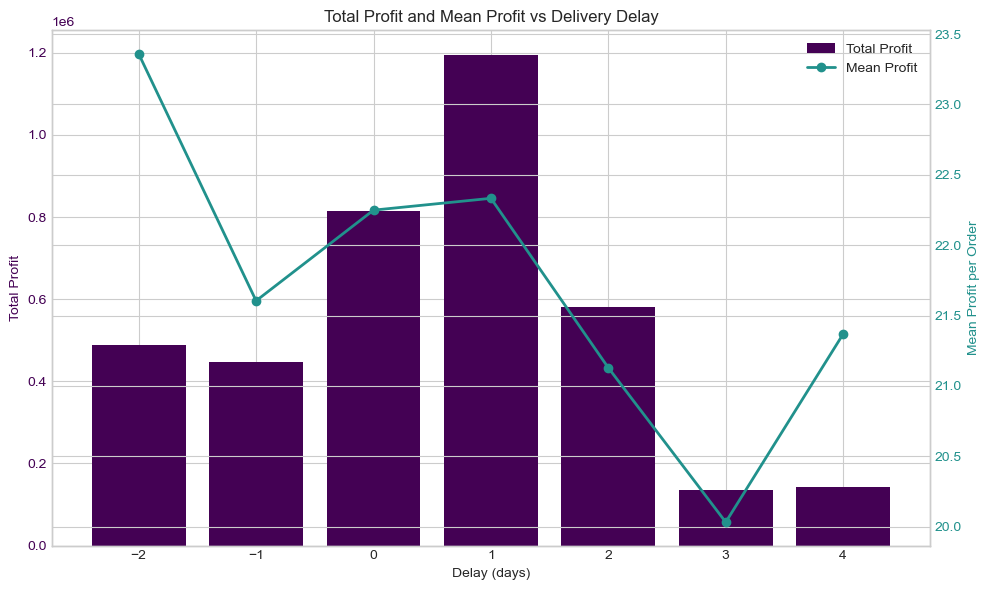

In [60]:
# Aggregate metrics by delay
profit_metrics = (
    df.groupby('Delay')['Benefit per order']
    .agg(
        mean_profit='mean',
        total_profit='sum'
    )
    .reset_index()
    .sort_values('Delay')
)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bars → Total Profit
ax1.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Total Profit', color=primary_color)
ax1.tick_params(axis='y', labelcolor=primary_color)

# Line → Mean Profit
ax2 = ax1.twinx()
ax2.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    color=accent_color,
    marker='o',
    linewidth=2,
    label='Mean Profit'
)
ax2.set_ylabel('Mean Profit per Order', color=accent_color)
ax2.tick_params(axis='y', labelcolor=accent_color)

# Title
plt.title('Total Profit and Mean Profit vs Delivery Delay')

# Optional legend fix (combined)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

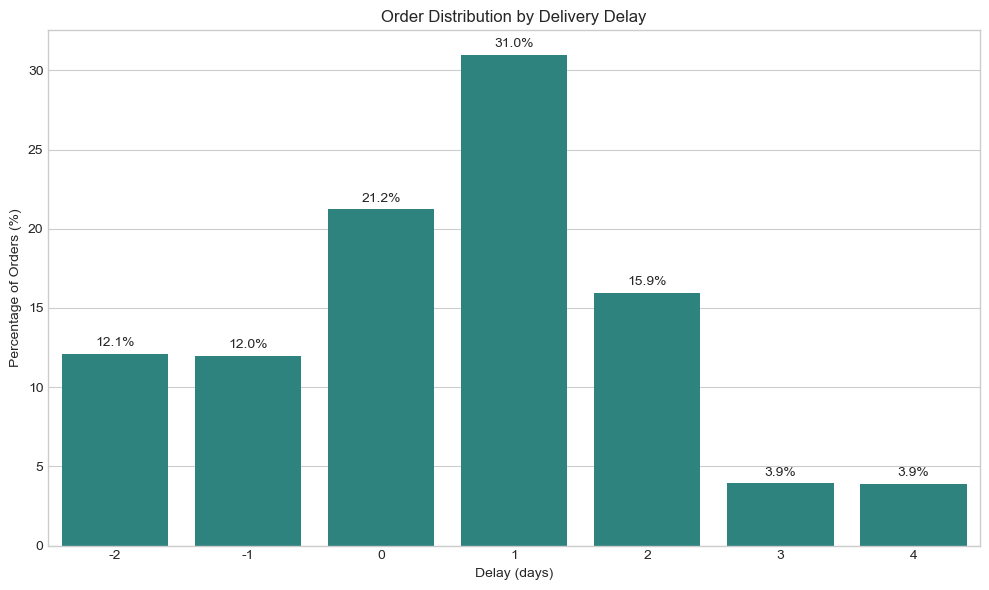

In [61]:
# Calculate percentage distribution of delay
delay_pct = (
    df['Delay']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

delay_pct.columns = ['Delay', 'Percentage']
delay_pct = delay_pct.sort_values('Delay')

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Delay',
    y='Percentage',
    data=delay_pct,
    color=accent_color
)

plt.xlabel('Delay (days)')
plt.ylabel('Percentage of Orders (%)')
plt.title('Order Distribution by Delivery Delay')

# Add percentage labels
for i, val in enumerate(delay_pct['Percentage']):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center')

plt.tight_layout()
plt.show()

In [62]:
df_delay = df[df['Delay'] >= 1]

In [63]:
def plot_profit_by_category(data, column):
    temp = (
        data.groupby(column)['Benefit per order']
        .sum()
        .sort_values()
        / 1e6   # convert to millions
    )

    plt.figure(figsize=(8, 5))
    colors = plt.cm.viridis(np.linspace(0, 1, len(temp)))

    temp.plot(kind='barh', color=colors)

    plt.xlabel('Total Profit (Million $)')
    plt.title(f'Profit by {column} (Delayed Orders)')
    plt.show()

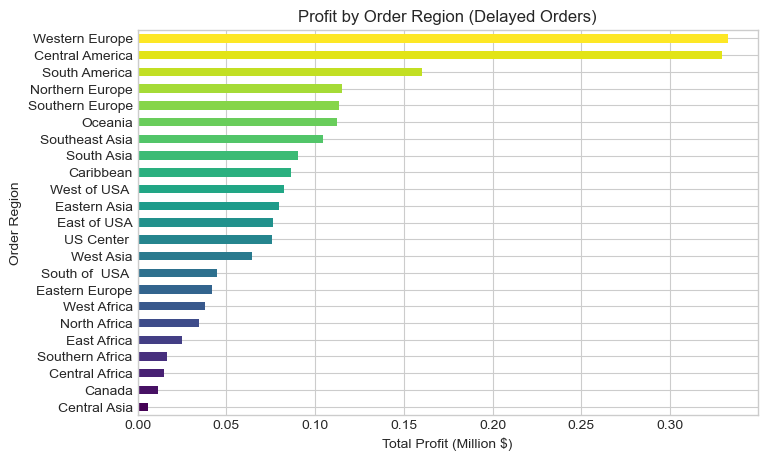

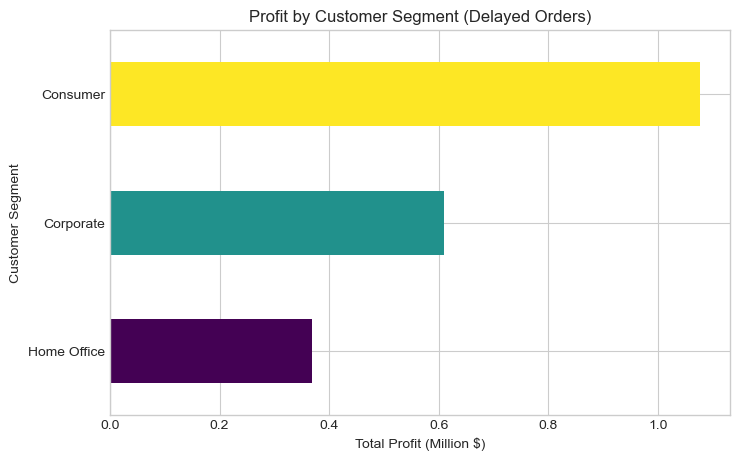

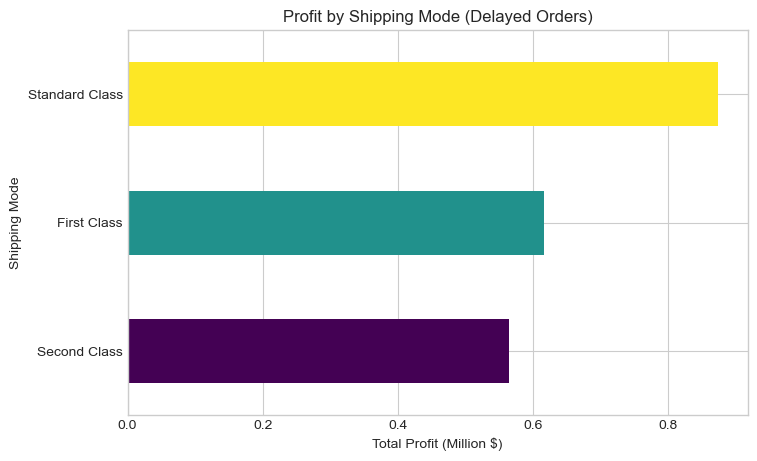

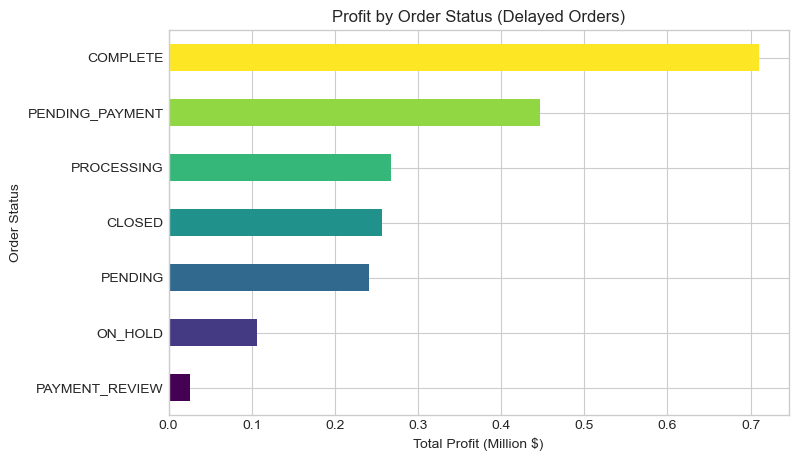

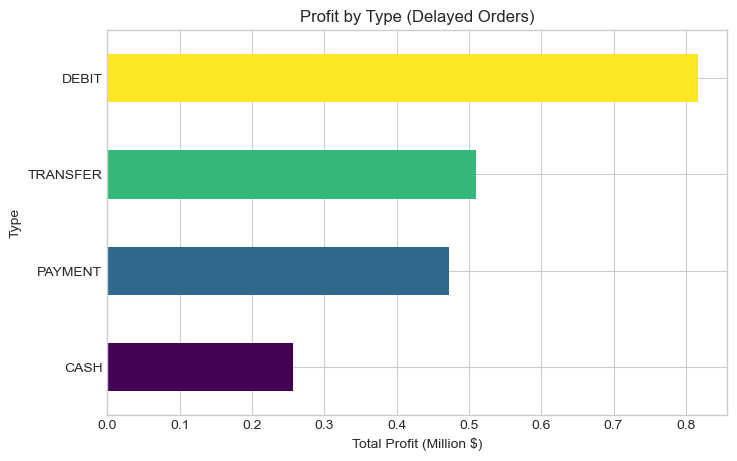

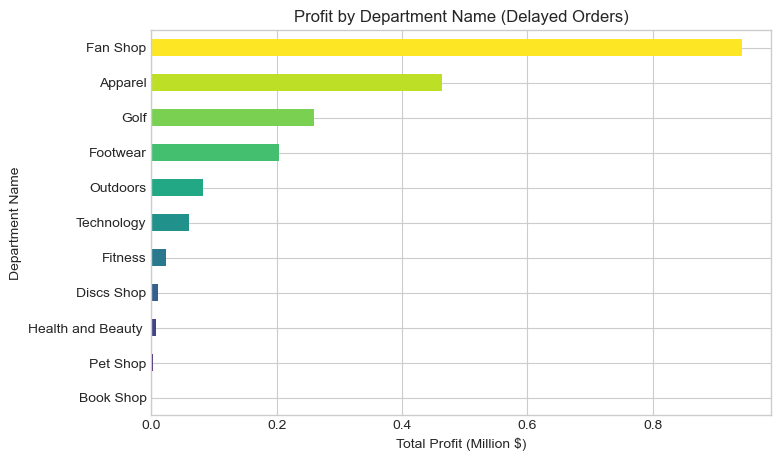

In [64]:
plot_profit_by_category(df_delay, 'Order Region')
plot_profit_by_category(df_delay, 'Customer Segment')
plot_profit_by_category(df_delay, 'Shipping Mode')
plot_profit_by_category(df_delay, 'Order Status')
plot_profit_by_category(df_delay, 'Type')
plot_profit_by_category(df_delay, 'Department Name')

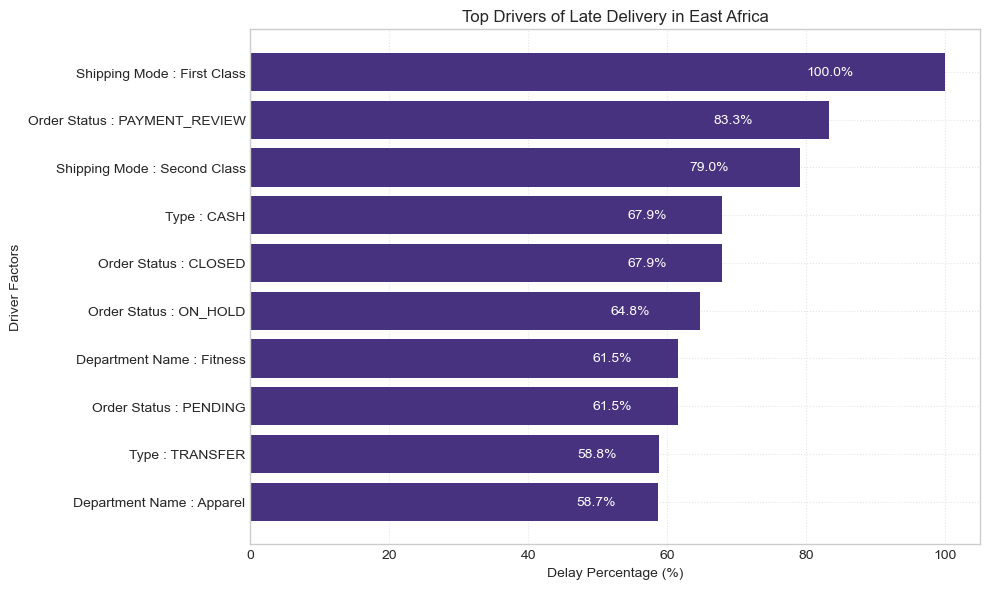

In [65]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    # Plot
    plt.figure(figsize=(10, 6))

    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")

    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    # Labels inside bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - max(width * 0.2, 2),
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.tight_layout()
    plt.show()

top_drivers_for_region('East Africa')
    

In [66]:
def plot_top_delay_drivers(df, driver, top_n=10, region=None):
    
    data = df.copy()
    
    # Optional region filter
    if region:
        data = data[data['Order Region'] == region]
    
    # Aggregate
    temp = (
        data.groupby(driver)
        .agg(
            total_orders=('Delay', 'count'),
            late_orders=('Is_Delayed', 'sum')
        )
        .reset_index()
    )
    
    # Calculate delay %
    temp['delay_pct'] = (temp['late_orders'] / temp['total_orders']) * 100
    
    # Sort + take top N
    temp = temp.sort_values('delay_pct', ascending=False).head(top_n)
    
    # Plot
    plt.figure(figsize=(9, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(temp)))
    bars = plt.barh(temp[driver].astype(str), temp['delay_pct'], color=colors)
    
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel(driver)
    
    title = f"Top {top_n} Delay Drivers by {driver}"
    if region:
        title += f" ({region})"
    
    plt.title(title)
    plt.gca().invert_yaxis()
    
    # Add labels
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va='center'
        )
    
    plt.tight_layout()
    plt.show()

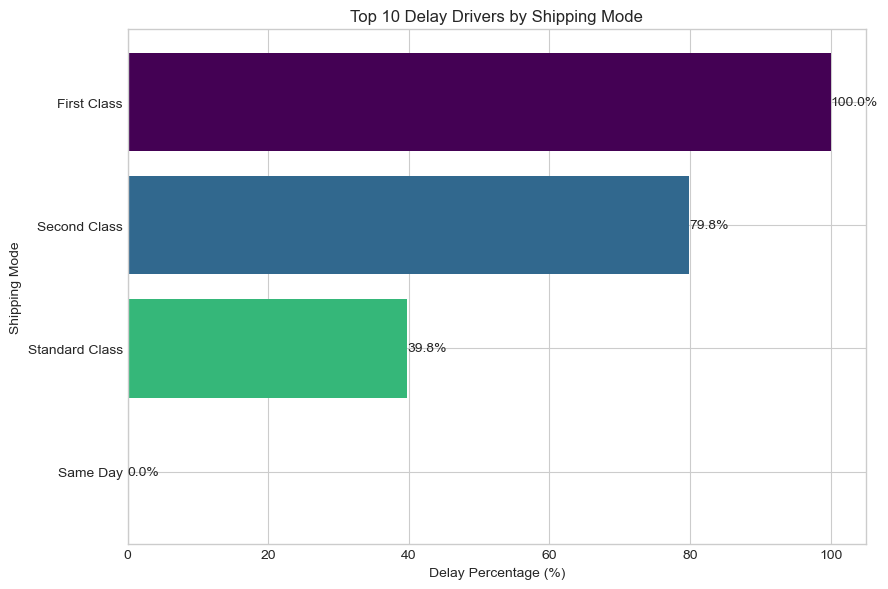

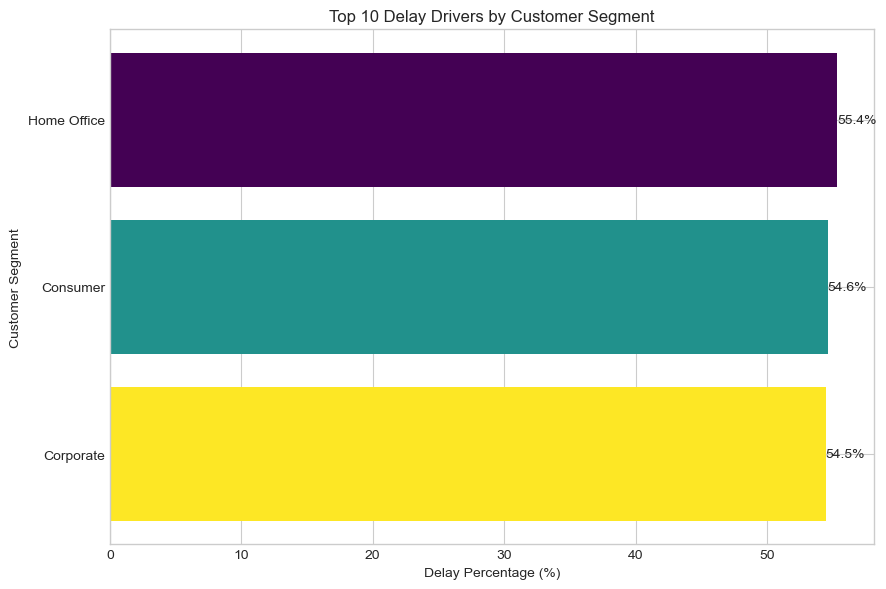

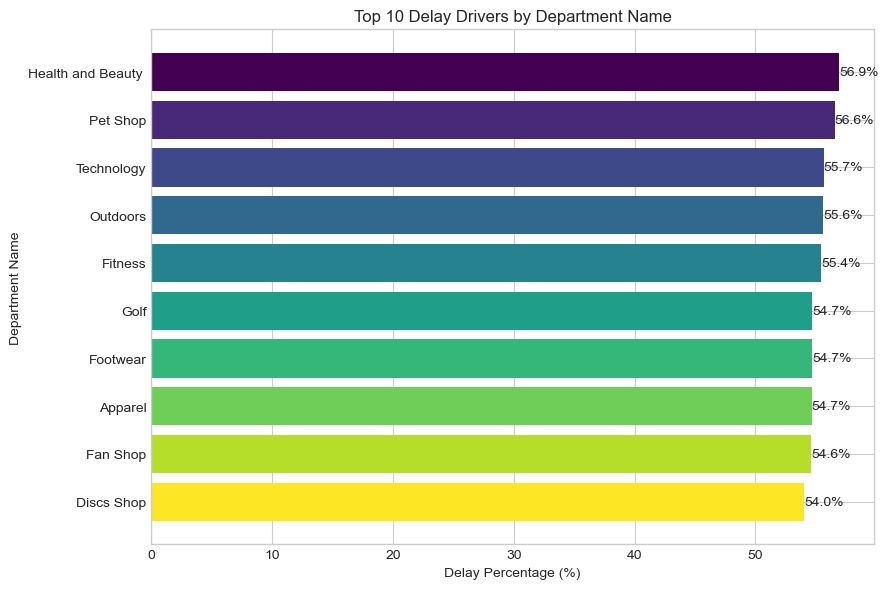

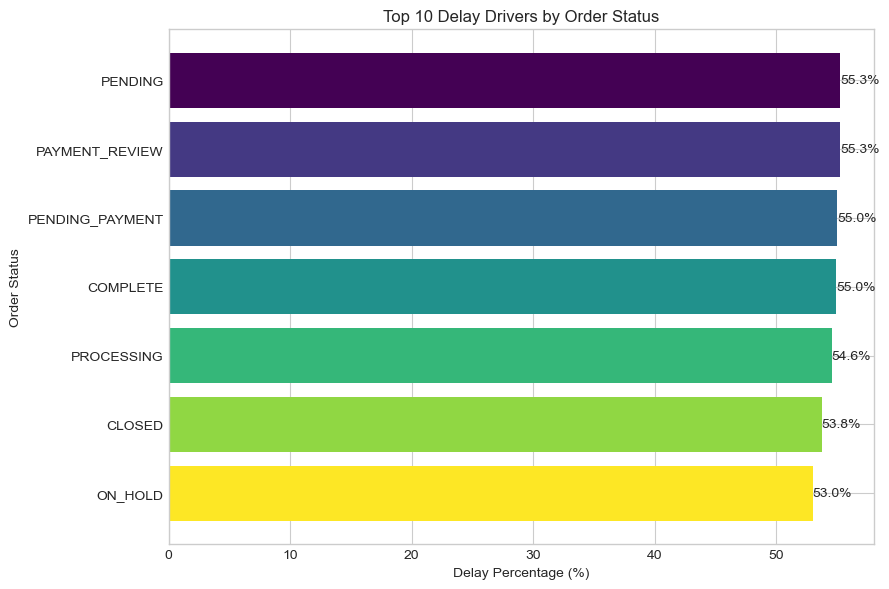

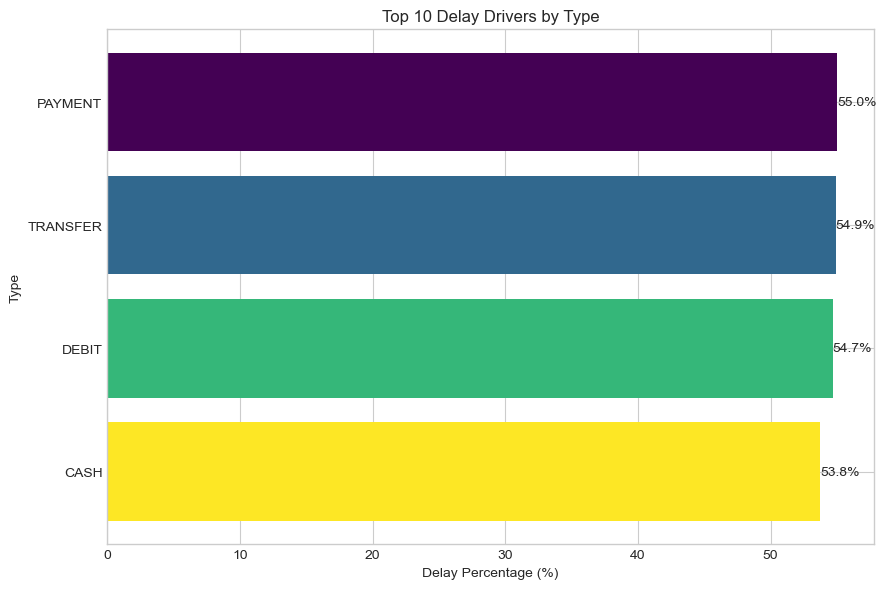

In [67]:
plot_top_delay_drivers(df, 'Shipping Mode')
plot_top_delay_drivers(df, 'Customer Segment')
plot_top_delay_drivers(df, 'Department Name')
plot_top_delay_drivers(df, 'Order Status')
plot_top_delay_drivers(df, 'Type')

In [68]:
# Delay % by Month, Day of Week, Hour

# By Month
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100


# By Day of Week
delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100


# By Hour
delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [69]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


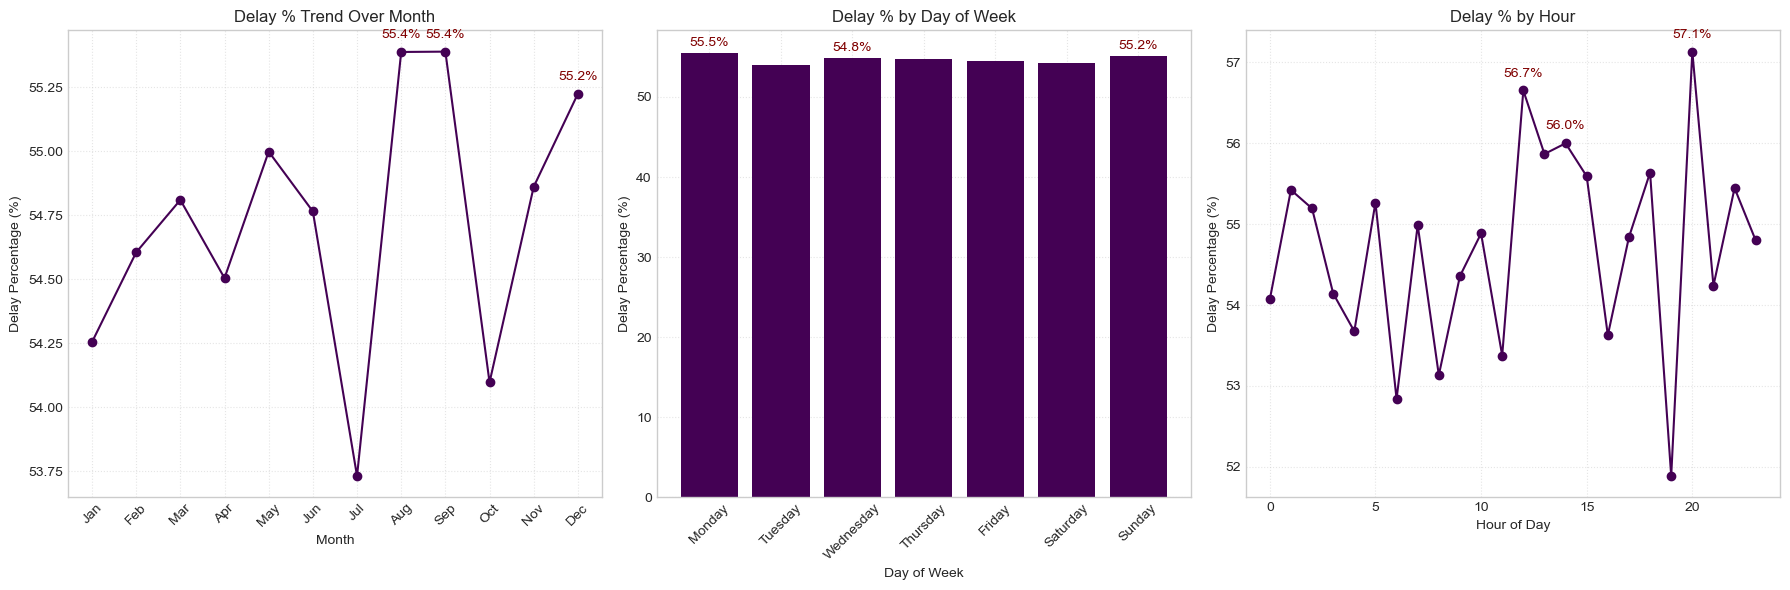

In [70]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# ------------------ Subplot 1: Delay % by Month ------------------
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'],
         marker='o', color=primary_color)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )


# ------------------ Subplot 2: Delay % by Day ------------------
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)

ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(
        row['order_day'],
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color=danger_color
    )


# ------------------ Subplot 3: Delay % by Hour ------------------
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'],
         marker='o', color=primary_color)

ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_hour'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )


plt.tight_layout()
plt.show()

In [71]:
# Features and target
X = df[
    ['Type', 'Days for shipment (scheduled)', 'Category Name',
     'Customer Segment', 'Department Name', 'Order Region',
     'Shipping Mode', 'order_month', 'order_hour']
]

y = df['Late_delivery_risk']

In [72]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in X_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [74]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

In [77]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,0.745000,0.799684,0.740338,0.768868
2,Random Forest,0.746795,0.806051,0.734832,0.768796
3,Gradient Boosting,0.724510,0.893295,0.589543,0.710308
0,Logistic,0.684832,0.835102,0.560546,0.670818


In [78]:
# Using pip
!pip install xgboost

In [79]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

In [80]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [81]:
y_pred = xgb.predict(X_test)

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7269
Precision: 0.8814
Recall: 0.6046
F1 Score: 0.7172
